# 9 — Globe base maps: ocean, land, lakes, rivers

This notebook explores Digital-Earth's **globe context layers** — the Natural-Earth fills and lines you drape on a projected `Map(globe=True)` to build a base map:

- `ocean()` — fills the whole projection **disc** with the ocean colour (network-free, exact).
- `land()` / `lakes()` — fill Natural-Earth **polygons**, re-closed at the projection limb into finite rings so nothing wraps across the figure.
- `coastlines()` / `borders()` / `rivers()` — **line** layers, split at the limb.

All of these draw **beneath the data** (z-order: ocean < land < lakes < data < coastlines) and are clipped to the projection boundary when the frame is applied on `render()` / `save()` / `show()`. The recipe stays Cartopy-free: **pyramids** reprojects, **digitalearth** re-closes the rings at the limb, **cleopatra** draws the static frame.

> Natural-Earth layers download on first use (then cache). Every networked cell below is wrapped so the notebook always executes cleanly — the `ocean()` disc fill works with no network at all.

## Setup

Imports, a synthetic **global** field (so a globe always has data on its near side), and a small helper that draws Natural-Earth layers but degrades gracefully when offline.

In [1]:
%matplotlib inline
import numpy as np
from pathlib import Path
from pyramids.dataset import Dataset
from digitalearth.scene import Map, projections

# A synthetic 1-degree global lon/lat field — smooth, so the fills read clearly underneath it.
ny, nx = 180, 360
lat = np.linspace(90, -90, ny)[:, None]
lon = np.linspace(-180, 180, nx)[None, :]
field = (np.cos(np.deg2rad(lat)) * 25 + 8 * np.sin(np.deg2rad(3 * lon))) * np.ones((ny, nx))
GLOBAL = Dataset.create_from_array(arr=field.astype('float32'),
                                   geo=(-180.0, 1.0, 0.0, 90.0, 0.0, -1.0), epsg=4326)

def safe(label, *calls):
    """Run Natural-Earth draw calls, reporting (not raising) if the data is unreachable."""
    try:
        for fn in calls:
            fn()
    except Exception as exc:
        print(f'{label}: natural-earth unavailable ({type(exc).__name__}) — skipped')

print('global field:', GLOBAL.rows, 'x', GLOBAL.columns)

2026-05-31 20:49:38 | INFO | pyramids.base.config | Logging is configured.


global field: 180 x 360


## 1. Ocean disc fill (no network)

`ocean()` on a globe fills the projection **boundary disc** with the ocean colour and lets land overlay it — exact and cheap, and it needs no Natural-Earth download. Here it is on its own with a graticule.

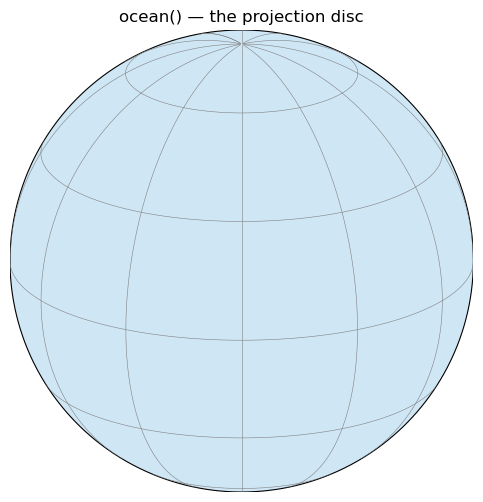

In [2]:
m = Map(crs=projections.orthographic(lon=-30, lat=20), globe=True, figsize=(6, 6))
m.ocean()
m.graticule(lon_step=30, lat_step=30)
m.set_global()
m.set_title('ocean() — the projection disc')
m.render()
m.fig;

## 2. A full globe base map

Stack the context layers in z-order: `ocean()` (disc) → `land()` / `lakes()` (filled polygons, re-closed at the limb) → `coastlines()` / `borders()` (lines). The fills are clipped to the disc on `render()`.

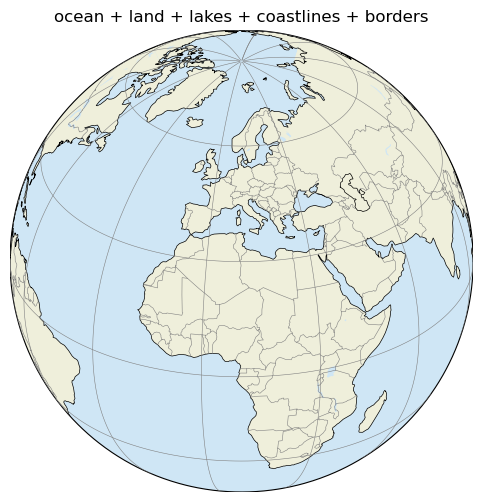

In [3]:
m = Map(crs=projections.orthographic(lon=10, lat=30), globe=True, figsize=(6, 6))
m.ocean()
safe('base map', lambda: m.land(resolution='110m'),
     lambda: m.lakes(resolution='110m'),
     lambda: m.coastlines(resolution='110m'),
     lambda: m.borders(resolution='110m'))
m.graticule(lon_step=30, lat_step=30)
m.set_global()
m.set_title('ocean + land + lakes + coastlines + borders')
m.render()
m.fig;

## 3. Rivers

`rivers()` is a **line** layer (Natural-Earth river/lake centerlines), split at the projection limb like coastlines. Shown over land on a globe centred on Africa/Europe.

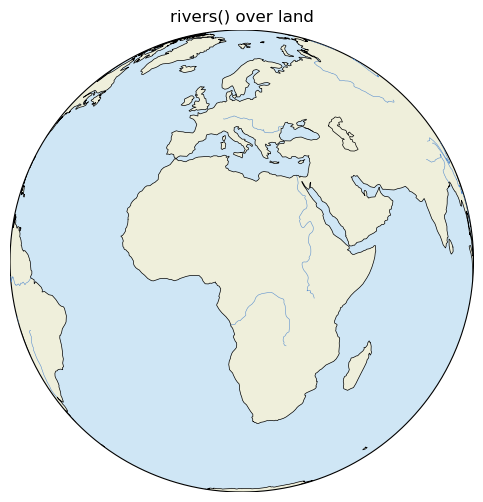

In [4]:
m = Map(crs=projections.orthographic(lon=15, lat=10), globe=True, figsize=(6, 6))
m.ocean()
safe('rivers', lambda: m.land(resolution='110m'),
     lambda: m.rivers(resolution='110m'),
     lambda: m.coastlines(resolution='110m'))
m.set_global()
m.set_title('rivers() over land')
m.render()
m.fig;

## 4. Data over a globe base map (z-order)

The fills sit **below** the data. Draw the ocean disc, then the global field, then coastlines on top — the raster covers the ocean where it has data, and coastlines stay crisp above it.

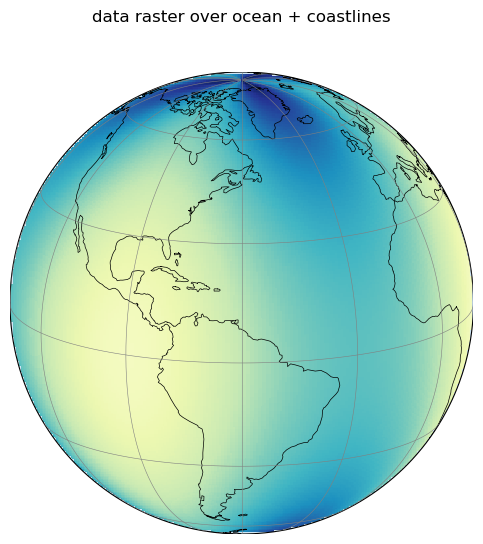

In [5]:
m = Map(crs=projections.orthographic(lon=-60, lat=15), globe=True, figsize=(6, 6))
m.ocean()
m.imshow(GLOBAL, cmap='YlGnBu_r')
safe('overlay', lambda: m.coastlines(resolution='110m'))
m.graticule(lon_step=30, lat_step=30)
m.set_global()
m.set_title('data raster over ocean + coastlines')
m.render()
m.fig;

## 5. Fills on other projection boundaries

The same fills work on any framed projection — a **rounded-rectangle** boundary (Robinson) and a **rectangular** one (Web Mercator). The limb-closure adapts to whatever boundary `projection_frame` returns.

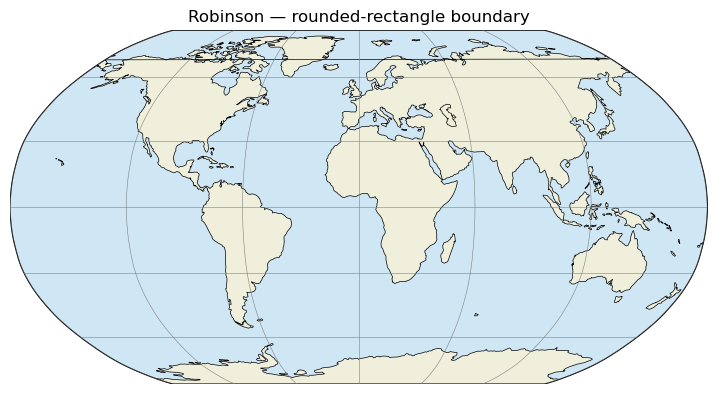

In [6]:
m = Map(crs=projections.robinson(lon=0), globe=True, figsize=(9, 5))
m.ocean()
safe('robinson', lambda: m.land(resolution='110m'), lambda: m.coastlines(resolution='110m'))
m.graticule(lon_step=60, lat_step=30)
m.set_global()
m.set_title('Robinson — rounded-rectangle boundary')
m.render()
m.fig;

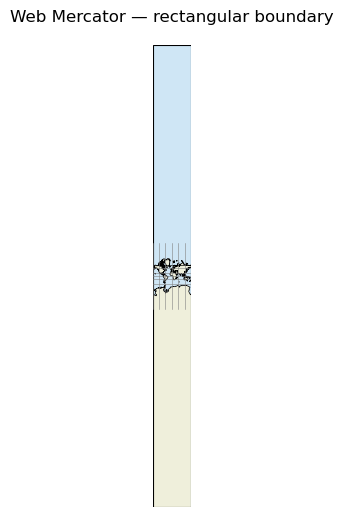

In [7]:
m = Map(crs=projections.web_mercator(), globe=True, figsize=(7, 6))
m.ocean()
safe('mercator', lambda: m.land(resolution='110m'), lambda: m.coastlines(resolution='110m'))
m.graticule(lon_step=60, lat_step=30)
m.set_global()
m.set_title('Web Mercator — rectangular boundary')
m.render()
m.fig;

## 6. Saving

`save()` applies the frame (boundary + clip + graticule) and writes the figure. The fills are clipped to the boundary in the saved file.

saved: C:\gdrive\algorithms\Visualization\Digital-Earth\docs\examples\globe_basemap.png | 97541 bytes


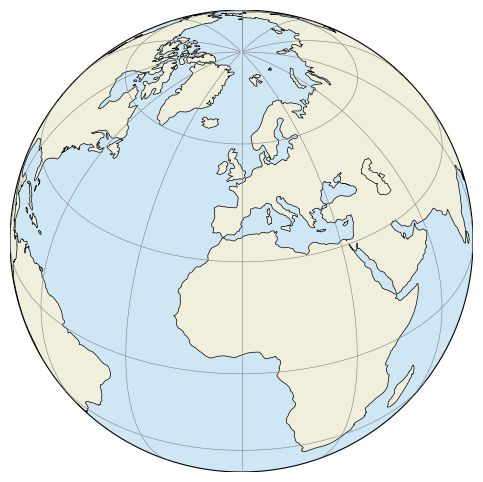

In [8]:
out = Path('globe_basemap.png')
m = Map(crs=projections.orthographic(lon=0, lat=35), globe=True, figsize=(6, 6))
m.ocean()
safe('save', lambda: m.land(resolution='110m'), lambda: m.coastlines(resolution='110m'))
m.graticule(); m.set_global()
m.save(str(out))
print('saved:', out.resolve(), '|', out.stat().st_size, 'bytes')
out.unlink()  # clean up the example artifact